In [5]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
from Bio import motifs
from matplotlib import pyplot as plt
from utils import draw_tf_heatmap , annotate_region
import dask.dataframe as dd
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region


In [6]:
data_test='cisbpbulk'
inputfolder = '/data2st2/junyi/output/atac1112/tobiasbam/BULK/BIND/'

In [7]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)
df_important_TF.columns=['TF']
df_tbffile = pd.read_csv(tbffile, sep='\t')

/tmp/ipykernel_4029400/4282565885.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tbffile = pd.read_csv(tbffile, sep='\t')


In [8]:
df = df_tbffile
motif_similarity_fdr = 0.001,
orthologous_identity_threshold  = 0.0
df.rename(columns={'#motif_id':"MotifID",
                    'gene_name':"TF",
                    'motif_similarity_qvalue': "MotifSimilarityQvalue",
                    'orthologous_identity': "OrthologousIdentity",
                    'description': "Annotation" }, inplace=True)
df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
        (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [9]:
df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
#df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

df_direct_annot.to_csv(os.path.join(outdir, 'motif_TF_annotated.tsv'), index=False)
df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"
dict_id2tf = dict(zip(df_direct_annot['soure_name'], df_direct_annot['TF']))
motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
#motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]
direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


/tmp/ipykernel_4029400/747042444.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
/tmp/ipykernel_4029400/747042444.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"


In [10]:
# direct_motifs = []
# names = []
# parsed_TFs= []
# for f in files:
#     bn = os.path.basename(f).removesuffix('.cb')
#     if bn not in direct_motif_TFs['MotifID'].values:
#         #print(f"Skipping {bn} as it is not in the important TF list.")
#         continue
#     tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
#     try:
#         with open(f) as handle:
#             m = motifs.read(handle, "ClusterBuster")
#             direct_motifs.append(m)
#             names.append(bn)
#             parsed_TFs.append(tf_tmp)
#             if 'MA0859.1' in record.name:
#                 print("here")

#     except ValueError:
#         with open(f) as handle:
#             records = motifs.parse(handle, "ClusterBuster")
#             for record in records:
#                 if 'MA0859.1' in record.name:
#                     print("here")
#                 record.name = bn+"#"+record.name
#                 direct_motifs.append(record)
#                 names.append(record.name)
#                 parsed_TFs.append(tf_tmp)

# mapdict = dict(zip(names, parsed_TFs))

In [11]:
extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [12]:
TOBIAS_Rsults = glob.glob(f'{inputfolder}/*.bw/bindetect_results.xlsx')

In [13]:
TOBIAS_Rsults

['/data2st2/junyi/output/atac1112/tobiasbam/BULK/BIND/AMY_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/BULK/BIND/PFC_MC_footprints.bw/bindetect_results.xlsx',
 '/data2st2/junyi/output/atac1112/tobiasbam/BULK/BIND/HIP_MC_footprints.bw/bindetect_results.xlsx']

# Merge all TOBIAS results on TF level

In [14]:
%%capture
# ignore cell outputs for this cell
results = pd.DataFrame()
full = pd.DataFrame()
full_results = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    df_tobias['MotifID'] = df_tobias['name'].str.split('#').str[0]
    df_tobias['source_name'] = df_tobias['name'].str.split('#').str[1]
    df_tobias['TF']=df_tobias['source_name'].map(dict_id2tf)
    df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()
    df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    #df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)
    # df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    # df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)
    df_expanded = df_tobias.copy()
    df_expanded['TFexpand'] = df_expanded['TF']

    # df_expanded
    df_expanded_mean = df_expanded.groupby('TFexpand').mean()
    df_expanded_mean['TF'] = df_expanded_mean.index
    df_expanded_mean['ctname'] = ctname
    df_expanded_mean['Region'] = region

    full_results = pd.concat([full_results, df_tobias], axis=0)
    results = pd.concat([results, df_expanded_mean], axis=0)

# Vizualize the results as heatmap

In [15]:
def add_columns(results):
    results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    results['log2FC'] = results['MC_MW_change']
    results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results
full_results = add_columns(full_results)
avg_results = add_columns(results)
full_results_filtered = full_results[full_results['MC_MW_highlighted']==True]
#full_results_filtered = full_results[full_results.FDR < 0.05]
full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
full_results_filtered.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)

/tmp/ipykernel_4029400/3525741300.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
/tmp/ipykernel_4029400/3525741300.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
/tmp/ipykernel_4029400/3525741300.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [16]:
#results=avg_results[avg_results.FDR <0.05]
results=full_results[full_results.FDR < 0.01]
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
results['Regulation']=results['Regulation'].astype(float)

/tmp/ipykernel_4029400/1483815915.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
/tmp/ipykernel_4029400/1483815915.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
/tmp/ipykernel_4029400/1483815915.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [17]:
avg_results['nlogp'] = -np.log10(avg_results['FDR'] + 1e-300) * np.sign(avg_results['log2FC'])
avg_results['Regulation'] = avg_results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
avg_results['Regulation']=avg_results['Regulation'].astype(float)
avg_results.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_TF_activity_summary_significant_avg_{data_test}_TFs.csv')
full_results_filtered['nlogp'] = -np.log10(full_results_filtered['FDR'] + 1e-300) * np.sign(full_results_filtered['log2FC'])
full_results_filtered['Regulation'] = full_results_filtered['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
full_results_filtered['Regulation']=full_results_filtered['Regulation'].astype(float)
full_results_filtered.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_TF_activity_summary_significant_avg_{data_test}_TFs.csv')
full_results_filtered.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_TF_activity_summary_significant_unique_{data_test}_TFs.csv')


/tmp/ipykernel_4029400/3657976874.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered['nlogp'] = -np.log10(full_results_filtered['FDR'] + 1e-300) * np.sign(full_results_filtered['log2FC'])
/tmp/ipykernel_4029400/3657976874.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered['Regulation'] = full_results_filtered['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
/tmp/ipykernel_4029400/3657976874.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy 

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


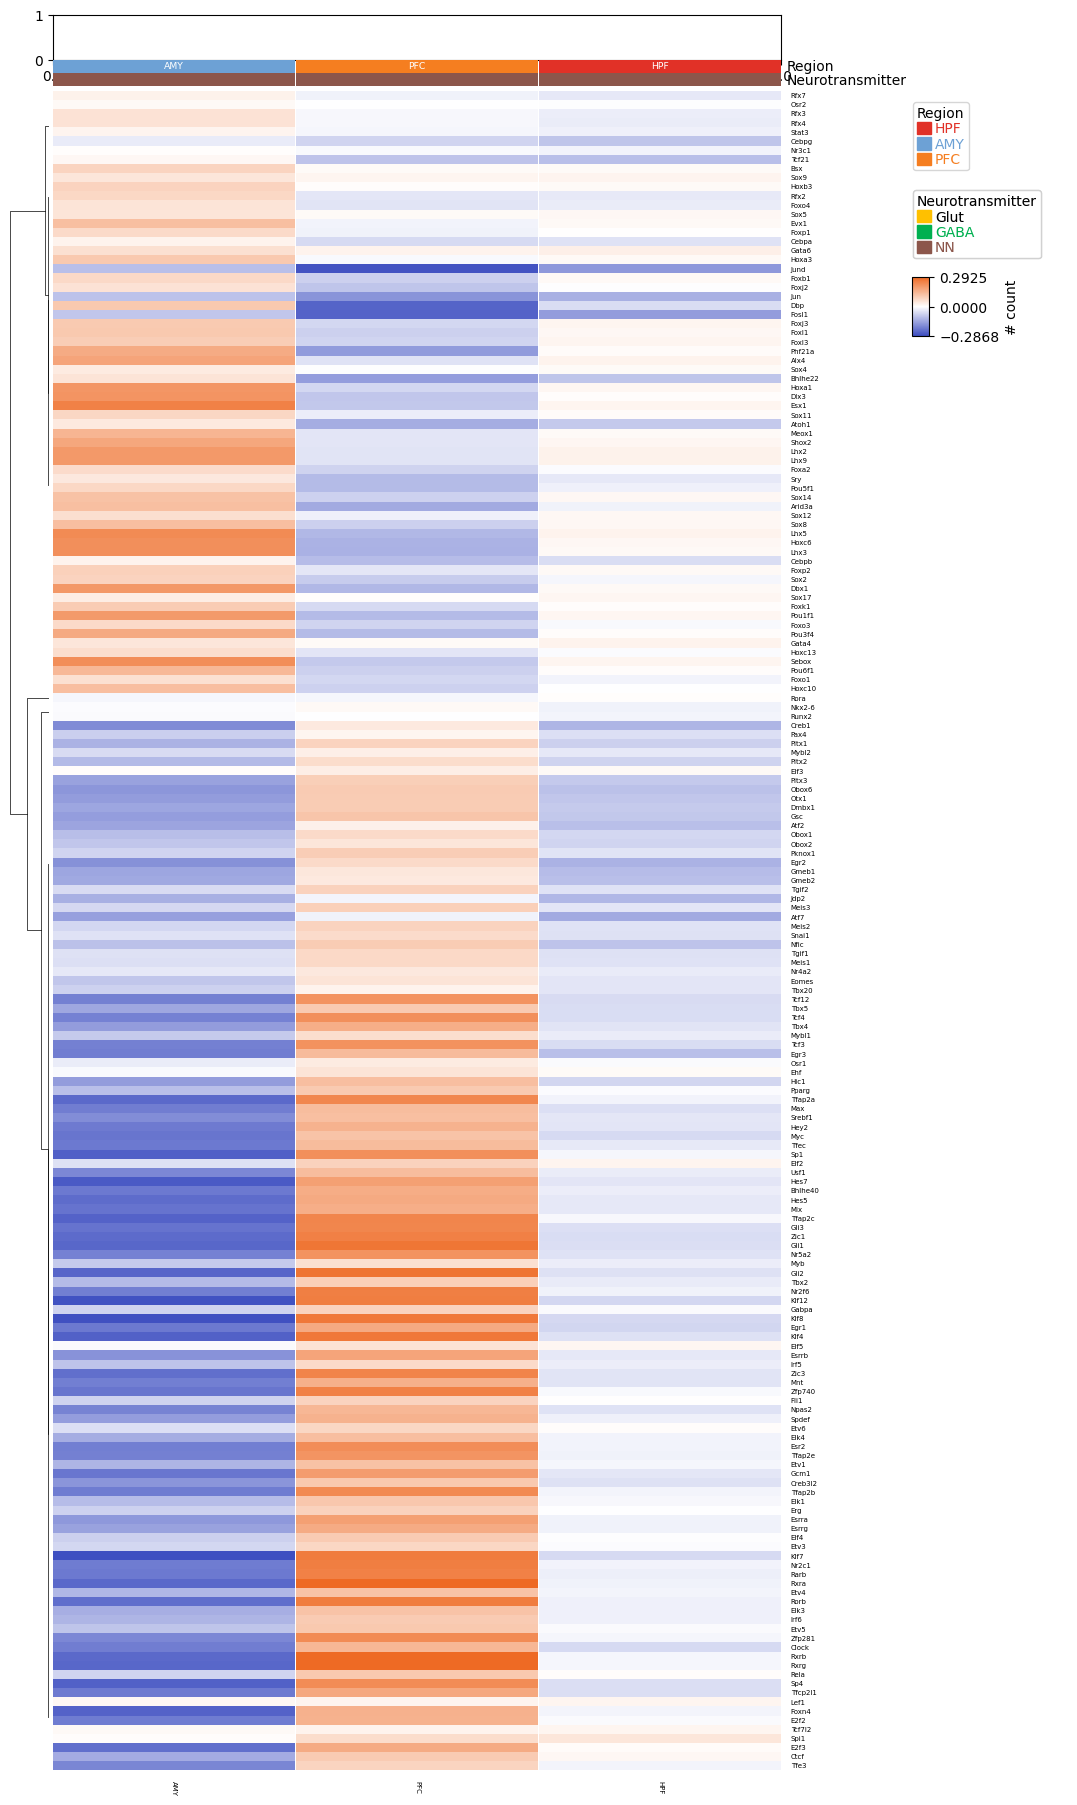

In [19]:

# 修改了 my_module.py 后，重新加载
importlib.reload(utils)

# cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(15,15)
#                      , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_{data_test}.pdf')
cm = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC", clipping=100,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_NN_{data_test}.pdf')
# cmavg = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter!='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_N_avg.pdf')
# cmavgNN = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter=='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_NN_avg.pdf')
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)
mat=cm.data2d.loc[row_names]
mat.to_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND_mat_{data_test}.csv')
# matavg = cmavg.data2d.loc[list(cmavg.row_order)[0]]
# matavg.to_csv('/data2st1/junyi/output/atac1112/tobias/BIND_matavg.csv')
# denrow = cm.dendrogram_row
# cm.dendrogram_row.dendrogram.keys()
# n = len(cm.dendrogram_row.dendrogram["leaves"])
# k = 10
# labels = np.repeat(np.arange(k), n//k + 1)[:n]

In [26]:
full_selected = full_results[full_results.FDR < 0.05]
full_selected['absLog2FC'] = full_selected['log2FC'].abs()
full_selected.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
full_selected.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)

/tmp/ipykernel_4029400/2487230757.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_selected['absLog2FC'] = full_selected['log2FC'].abs()
/tmp/ipykernel_4029400/2487230757.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_selected.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
/tmp/ipykernel_4029400/2487230757.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#r

In [27]:
full_selected

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Gene,Neurotransmitter,Region Subclass,log2FC,FDR,Subclass,Region,status,celltype.L2,absLog2FC
213,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_cisbp__M01816,167608,0.03602,56664,0.03995,60720,-0.33487,...,Jund,NN,PFC,-0.33487,2.655880e-213,,PFC,Down,,0.33487
5,metacluster_121.1cisbp__M02400_None,metacluster_121.1#cisbp__M02400,None,C_metacluster_121.1#cisbp__M02401,190031,0.02581,57714,0.02286,50521,0.29248,...,Rxrg,NN,PFC,0.29248,4.313110e-209,,PFC,Up,,0.29248
67,metacluster_64.1cisbp__M00181_None,metacluster_64.1#cisbp__M00181,None,C_metacluster_121.1#cisbp__M02401,234295,0.02449,68827,0.02164,60290,0.29177,...,Rxra,NN,PFC,0.29177,1.294620e-217,,PFC,Up,,0.29177
7,metacluster_121.1cisbp__M02402_None,metacluster_121.1#cisbp__M02402,None,C_metacluster_121.1#cisbp__M02401,197488,0.02578,60020,0.02283,52565,0.29173,...,Rxrb,NN,PFC,0.29173,2.482210e-216,,PFC,Up,,0.29173
99,metacluster_163.1cisbp__M00134_None,metacluster_163.1#cisbp__M00134,None,C_metacluster_163.1#cisbp__M08021,343623,0.09674,80179,0.09840,86028,-0.28685,...,Klf7,NN,AMY,-0.28685,1.635310e-226,,AMY,Down,,0.28685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,metacluster_183.3cisbp__M01486_None,metacluster_183.3#cisbp__M01486,None,C_metacluster_191.3#cisbp__M00157,97537,0.07209,27088,0.06979,27314,0.00081,...,Fli1,NN,HPF,0.00081,1.455680e-03,,HPF,Up,,0.00081
327,metacluster_8.2cisbp__M01307_None,metacluster_8.2#cisbp__M01307,None,C_metacluster_8.2#cisbp__M01307,91276,0.02622,23048,0.02532,22715,-0.00061,...,Runx2,NN,PFC,-0.00061,4.155580e-02,,PFC,Down,,0.00061
236,metacluster_1.10cisbp__M00421_None,metacluster_1.10#cisbp__M00421,None,C_metacluster_1.10#cisbp__M00421,110773,0.01529,11779,0.01515,12162,0.00058,...,Hoxc10,NN,HPF,0.00058,4.526730e-02,,HPF,Up,,0.00058
266,metacluster_183.3cisbp__M01494_None,metacluster_183.3#cisbp__M01494,None,C_metacluster_191.3#cisbp__M00157,105265,0.06819,27931,0.06605,28139,-0.00039,...,Elf2,NN,HPF,-0.00039,3.292640e-02,,HPF,Down,,0.00039


In [28]:
full_selected

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Gene,Neurotransmitter,Region Subclass,log2FC,FDR,Subclass,Region,status,celltype.L2,absLog2FC
213,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_cisbp__M01816,167608,0.03602,56664,0.03995,60720,-0.33487,...,Jund,NN,PFC,-0.33487,2.655880e-213,,PFC,Down,,0.33487
5,metacluster_121.1cisbp__M02400_None,metacluster_121.1#cisbp__M02400,None,C_metacluster_121.1#cisbp__M02401,190031,0.02581,57714,0.02286,50521,0.29248,...,Rxrg,NN,PFC,0.29248,4.313110e-209,,PFC,Up,,0.29248
67,metacluster_64.1cisbp__M00181_None,metacluster_64.1#cisbp__M00181,None,C_metacluster_121.1#cisbp__M02401,234295,0.02449,68827,0.02164,60290,0.29177,...,Rxra,NN,PFC,0.29177,1.294620e-217,,PFC,Up,,0.29177
7,metacluster_121.1cisbp__M02402_None,metacluster_121.1#cisbp__M02402,None,C_metacluster_121.1#cisbp__M02401,197488,0.02578,60020,0.02283,52565,0.29173,...,Rxrb,NN,PFC,0.29173,2.482210e-216,,PFC,Up,,0.29173
99,metacluster_163.1cisbp__M00134_None,metacluster_163.1#cisbp__M00134,None,C_metacluster_163.1#cisbp__M08021,343623,0.09674,80179,0.09840,86028,-0.28685,...,Klf7,NN,AMY,-0.28685,1.635310e-226,,AMY,Down,,0.28685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,metacluster_183.3cisbp__M01486_None,metacluster_183.3#cisbp__M01486,None,C_metacluster_191.3#cisbp__M00157,97537,0.07209,27088,0.06979,27314,0.00081,...,Fli1,NN,HPF,0.00081,1.455680e-03,,HPF,Up,,0.00081
327,metacluster_8.2cisbp__M01307_None,metacluster_8.2#cisbp__M01307,None,C_metacluster_8.2#cisbp__M01307,91276,0.02622,23048,0.02532,22715,-0.00061,...,Runx2,NN,PFC,-0.00061,4.155580e-02,,PFC,Down,,0.00061
236,metacluster_1.10cisbp__M00421_None,metacluster_1.10#cisbp__M00421,None,C_metacluster_1.10#cisbp__M00421,110773,0.01529,11779,0.01515,12162,0.00058,...,Hoxc10,NN,HPF,0.00058,4.526730e-02,,HPF,Up,,0.00058
266,metacluster_183.3cisbp__M01494_None,metacluster_183.3#cisbp__M01494,None,C_metacluster_191.3#cisbp__M00157,105265,0.06819,27931,0.06605,28139,-0.00039,...,Elf2,NN,HPF,-0.00039,3.292640e-02,,HPF,Down,,0.00039


In [29]:
full_selected

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Gene,Neurotransmitter,Region Subclass,log2FC,FDR,Subclass,Region,status,celltype.L2,absLog2FC
213,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_cisbp__M01816,167608,0.03602,56664,0.03995,60720,-0.33487,...,Jund,NN,PFC,-0.33487,2.655880e-213,,PFC,Down,,0.33487
5,metacluster_121.1cisbp__M02400_None,metacluster_121.1#cisbp__M02400,None,C_metacluster_121.1#cisbp__M02401,190031,0.02581,57714,0.02286,50521,0.29248,...,Rxrg,NN,PFC,0.29248,4.313110e-209,,PFC,Up,,0.29248
67,metacluster_64.1cisbp__M00181_None,metacluster_64.1#cisbp__M00181,None,C_metacluster_121.1#cisbp__M02401,234295,0.02449,68827,0.02164,60290,0.29177,...,Rxra,NN,PFC,0.29177,1.294620e-217,,PFC,Up,,0.29177
7,metacluster_121.1cisbp__M02402_None,metacluster_121.1#cisbp__M02402,None,C_metacluster_121.1#cisbp__M02401,197488,0.02578,60020,0.02283,52565,0.29173,...,Rxrb,NN,PFC,0.29173,2.482210e-216,,PFC,Up,,0.29173
99,metacluster_163.1cisbp__M00134_None,metacluster_163.1#cisbp__M00134,None,C_metacluster_163.1#cisbp__M08021,343623,0.09674,80179,0.09840,86028,-0.28685,...,Klf7,NN,AMY,-0.28685,1.635310e-226,,AMY,Down,,0.28685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,metacluster_183.3cisbp__M01486_None,metacluster_183.3#cisbp__M01486,None,C_metacluster_191.3#cisbp__M00157,97537,0.07209,27088,0.06979,27314,0.00081,...,Fli1,NN,HPF,0.00081,1.455680e-03,,HPF,Up,,0.00081
327,metacluster_8.2cisbp__M01307_None,metacluster_8.2#cisbp__M01307,None,C_metacluster_8.2#cisbp__M01307,91276,0.02622,23048,0.02532,22715,-0.00061,...,Runx2,NN,PFC,-0.00061,4.155580e-02,,PFC,Down,,0.00061
236,metacluster_1.10cisbp__M00421_None,metacluster_1.10#cisbp__M00421,None,C_metacluster_1.10#cisbp__M00421,110773,0.01529,11779,0.01515,12162,0.00058,...,Hoxc10,NN,HPF,0.00058,4.526730e-02,,HPF,Up,,0.00058
266,metacluster_183.3cisbp__M01494_None,metacluster_183.3#cisbp__M01494,None,C_metacluster_191.3#cisbp__M00157,105265,0.06819,27931,0.06605,28139,-0.00039,...,Elf2,NN,HPF,-0.00039,3.292640e-02,,HPF,Down,,0.00039


# Region level analysis

In [33]:
df_regions = pd.DataFrame()
valid_files = []
unvalid_files = []
for idx, row in full_selected.iterrows():
    prefix = row['output_prefix']
    region = row['Region'].replace('HPF','HIP')
    subclass = row['Subclass']
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MC_bound.bed'
    #downbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MW_bound.bed'
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'
    upbed = f'{inputfolder}/{region}{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'

    # df_t = pd.read_csv(upbed, sep='\t')
    # df_t['TF'] = row['TF']
    # df_t['Region Subclass'] = row['Region Subclass']
    # df_regions = pd.concat([df_regions, df_t], axis=0)
    if os.path.exists(upbed):
        valid_files.append(upbed)
    else:
        unvalid_files.append(upbed)
    # if os.path.exists(downbed):
    #     valid_files.append(downbed)
    # else:
    #     unvalid_files.append(downbed)

In [34]:
upbed

'/data2st2/junyi/output/atac1112/tobiasbam/BULK/BIND//HIP_MC_footprints.bw/metacluster_4.4cisbp__M08041_None/metacluster_4.4cisbp__M08041_None_overview.txt'

In [35]:
len(unvalid_files)

0

In [36]:
df = dd.read_csv(valid_files, sep='\t', header=0,include_path_column="source_file")
#df.columns = ['chr','start','end','name','score','strand','peak_chr','peak_start','peak_end','bound','source_file']

In [69]:
df_filtered = df[(df['MC_bound']>0) | (df['MW_bound']>0)]
df_filtered['absLog2FC']  = df_filtered['MC_MW_log2fc'].abs()
df_filtered['Region Subclass'] = df_filtered['source_file'].str.split('/').str[9].str[:-17]
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HIP','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HPF_HPF','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('AMY_AMY','AMY')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('PFC_PFC','PFC')
df_filtered['names'] = df_filtered['peak_chr'].astype(str)+':'+df_filtered['peak_start'].astype(str)+'-'+df_filtered['peak_end'].astype(str)
df_filtered['Direction'] = df_filtered['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/dask/dataframe/core.py:4158: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('MC_MW_log2fc', 'object'))

  warnings.warn(meta_warning(meta))


In [70]:
df_regions= df_filtered.compute()

In [ ]:
# df_regions['names'] = df_regions['peak_chr'].astype(str)+':'+df_regions['peak_start'].astype(str)+'-'+df_regions['peak_end'].astype(str)
# df_regions['Direction'] = df_regions['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')

In [71]:
dict_tfbs2tf = dict(zip(df_direct_annot['TFBS_name'], df_direct_annot['TF']))

In [73]:
df_regions_f = df_regions[df_regions['absLog2FC'] >= 0.1]
df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

/tmp/ipykernel_4029400/2661574113.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)


In [75]:
df_regions_f.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,MW_score,MC_bound,MW_bound,MC_MW_log2fc,source_file,absLog2FC,Region Subclass,names,Direction,TF
4,chr1,3165033,3165042,metacluster_137.2cisbp__M01001_None,9.14333,-,chr1,3164802,3165303,0.01298,0.02208,0,1,-0.64519,/data2st2/junyi/output/atac1112/tobiasbam/BULK...,0.64519,PFC,chr1:3164802-3165303,Down,Jund
6,chr1,3210452,3210461,metacluster_137.2cisbp__M01001_None,9.14333,+,chr1,3210182,3210683,0.02458,0.03088,1,1,-0.29530,/data2st2/junyi/output/atac1112/tobiasbam/BULK...,0.29530,PFC,chr1:3210182-3210683,Down,Jund
9,chr1,3227562,3227571,metacluster_137.2cisbp__M01001_None,8.79758,+,chr1,3227430,3227931,0.01311,0.02632,0,1,-0.85767,/data2st2/junyi/output/atac1112/tobiasbam/BULK...,0.85767,PFC,chr1:3227430-3227931,Down,Jund
12,chr1,3249210,3249219,metacluster_137.2cisbp__M01001_None,8.79758,-,chr1,3249030,3249531,0.01403,0.02112,0,1,-0.49829,/data2st2/junyi/output/atac1112/tobiasbam/BULK...,0.49829,PFC,chr1:3249030-3249531,Down,Jund
13,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.12628,-,chr1,3309937,3310438,0.03891,0.05881,1,1,-0.55882,/data2st2/junyi/output/atac1112/tobiasbam/BULK...,0.55882,PFC,chr1:3309937-3310438,Down,Jund


In [ ]:
#df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated.csv')

In [ ]:
# df_Group = df_regions_f.groupby(['names', 'Region Subclass','Direction'], as_index=False).agg(
#     combined_TF=('TF', lambda x: '/'.join(x.astype(str))),
#     combined_TFBS=('TFBS_name', lambda x: '/'.join(x.astype(str)))
# )


In [76]:
df_regions_peaks = df_regions_f.drop_duplicates(subset=['peak_chr','peak_start','peak_end'])
df_regions_peaks.loc[:, ['peak_chr','peak_start','peak_end']].to_csv('/data2st1/junyi/output/atac1112/tobias/tobias_peaks.bed',sep='\t', index=False,header=False)
df_annotattion = annotate_region(df_regions_peaks,region_col='names', bedfile='/data2st1/junyi/generegion_vM23/genebody_selected.bed')

In [77]:
df_annotattion_columns = df_annotattion.loc[:,['names','gene_name','gene_id','gstart','gend','distance']]

In [78]:
df_merged_region = pd.merge(df_regions_f,df_annotattion_columns,how='left',on='names')

In [79]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,absLog2FC,Region Subclass,names,Direction,TF,gene_name,gene_id,gstart,gend,distance
0,chr1,3165033,3165042,metacluster_137.2cisbp__M01001_None,9.14333,-,chr1,3164802,3165303,0.01298,...,0.64519,PFC,chr1:3164802-3165303,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,40598
1,chr1,3210452,3210461,metacluster_137.2cisbp__M01001_None,9.14333,+,chr1,3210182,3210683,0.02458,...,0.29530,PFC,chr1:3210182-3210683,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0
2,chr1,3227562,3227571,metacluster_137.2cisbp__M01001_None,8.79758,+,chr1,3227430,3227931,0.01311,...,0.85767,PFC,chr1:3227430-3227931,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0
3,chr1,3249210,3249219,metacluster_137.2cisbp__M01001_None,8.79758,-,chr1,3249030,3249531,0.01403,...,0.49829,PFC,chr1:3249030-3249531,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0
4,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.12628,-,chr1,3309937,3310438,0.03891,...,0.55882,PFC,chr1:3309937-3310438,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0


In [80]:
def archr_distance_weight(d):
    d = abs(d)
    return np.exp(-d/5000) + np.exp(-1)

def copute_weighted_score(df_input):
    df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
    df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
    df_input["MW_Weighted"] = df_input["MW_score"] * df_input["distance_weight"]
    df_trimed = df_input[(df_input.distance <= 100000) & (df_input.distance >= -100000)]
    df_trimed_grouped =  df_trimed.groupby(['gene_name','Region Subclass']).sum().reset_index()
    df_trimed_grouped['log2FC'] = np.log2((df_trimed_grouped['MC_Weighted'] + 1e-10) / (df_trimed_grouped['MW_Weighted'] + 1e-10))
    df_trimed_grouped['Region subclass'] = df_trimed_grouped['Region Subclass']
    #Direction	Region	Neurotransmitter	Sex	Gene	Subclass
    df_trimed_grouped['Direction'] = df_trimed_grouped['log2FC'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_trimed_grouped['Sex'] = 'M'
    df_trimed_grouped['Gene'] = df_trimed_grouped['gene_name']
    df_trimed_grouped['Neurotransmitter'] = df_trimed_grouped['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    df_trimed_grouped['Subclass'] = df_trimed_grouped['Region Subclass']
    df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'] = df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'].str[4:]
    df_trimed_grouped['Region'] = df_trimed_grouped['Region Subclass'].str[:3].str.replace('HIP','HPF')
    return df_trimed_grouped

In [81]:
df_merged_region['distance_weight'] = df_merged_region['distance'].apply(archr_distance_weight)

In [82]:
df_merged_region["MC_Weighted"] = df_merged_region["MC_score"] * df_merged_region["distance_weight"]
df_merged_region["MW_Weighted"] = df_merged_region["MW_score"] * df_merged_region["distance_weight"]


In [84]:
df_module = pd.read_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND_mat_anno_cisbp.csv')

In [85]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Direction,TF,gene_name,gene_id,gstart,gend,distance,distance_weight,MC_Weighted,MW_Weighted
0,chr1,3165033,3165042,metacluster_137.2cisbp__M01001_None,9.14333,-,chr1,3164802,3165303,0.01298,...,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,40598,0.368177,0.004779,0.008129
1,chr1,3210452,3210461,metacluster_137.2cisbp__M01001_None,9.14333,+,chr1,3210182,3210683,0.02458,...,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0,1.367879,0.033622,0.042240
2,chr1,3227562,3227571,metacluster_137.2cisbp__M01001_None,8.79758,+,chr1,3227430,3227931,0.01311,...,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0,1.367879,0.017933,0.036003
3,chr1,3249210,3249219,metacluster_137.2cisbp__M01001_None,8.79758,-,chr1,3249030,3249531,0.01403,...,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0,1.367879,0.019191,0.028890
4,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.12628,-,chr1,3309937,3310438,0.03891,...,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0,1.367879,0.053224,0.080445


In [87]:
inputfolder

'/data2st2/junyi/output/atac1112/tobiasbam/BULK/BIND/'

In [88]:
for celltype in df_merged_region['Region Subclass'].unique():
    df_tmp = df_merged_region[df_merged_region['Region Subclass']==celltype]
    df_tmp.to_csv(os.path.join(inputfolder, f'tobias_regions_{celltype}.csv'), index=False)

In [89]:
df_tmp.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Direction,TF,gene_name,gene_id,gstart,gend,distance,distance_weight,MC_Weighted,MW_Weighted
4574278,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.12628,-,chr1,3309937,3310438,0.02168,...,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0,1.367879,0.029656,0.043526
4574279,chr1,3336088,3336097,metacluster_137.2cisbp__M01001_None,8.84406,+,chr1,3335813,3336314,0.02538,...,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0,1.367879,0.034717,0.058408
4574280,chr1,3399199,3399208,metacluster_137.2cisbp__M01001_None,9.14333,+,chr1,3398940,3399441,0.02701,...,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0,1.367879,0.036946,0.041378
4574281,chr1,3407649,3407658,metacluster_137.2cisbp__M01001_None,8.26673,+,chr1,3407330,3407831,0.25488,...,Up,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0,1.367879,0.348645,0.294108
4574282,chr1,3414915,3414924,metacluster_137.2cisbp__M01001_None,8.01852,-,chr1,3414636,3415137,0.02718,...,Down,Jund,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0,1.367879,0.037179,0.049244


In [ ]:
for module in df_module['Module'].unique():
    df_sub = df_module[df_module['Module'] == module]
    focus = df_sub['TF'].values
    df_merged_region_focus = df_merged_region[df_merged_region['TF'].isin(focus)]
    df_merged_region_focus_grouped = copute_weighted_score(df_merged_region_focus)
    df_merged_region_focus_grouped.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_{module}_gene_summary_cisbp.csv', index=False)

In [ ]:
# 计算95%分位点
top_95 = df_merged_region_focus_grouped['MC_MW_log2fc'].quantile(0.95)
low_95 = df_merged_region_focus_grouped['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_merged_region_focus_grouped['MC_MW_log2fc'].hist(bins=200, alpha=0.7, color='skyblue', edgecolor='black')
# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-10, 10)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_merged_region_focus_grouped['MC_MW_log2fc'].mean()
std_val = df_merged_region_focus_grouped['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_merged_region_focus_grouped)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
df_merged_region_focus_grouped['absLog2FC'] = df_merged_region_focus_grouped['log2FC'].abs()
df_merged_region_focus_grouped[df_merged_region_focus_grouped.absLog2FC > 0.1]

In [ ]:
df_merged_region_focus_grouped['Sex'] = 'M'

In [ ]:
df_merged_region.to_csv('/data2st1/junyi/output/atac1112/tobias/df_regions_all_fc1.csv')

In [ ]:
df_merged_DAR = pd.merge(df_regions_f, df_DAR, how='inner', left_on=['names','Region Subclass'], right_on=['names','Region Subclass'])

In [ ]:
df_merged_DAR['TF'] = df_merged_DAR['TFBS_name'].map(dict_tfbs2tf)

In [ ]:
df_merged_DAR.to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated.csv', index=False)

In [ ]:
# 计算95%分位点
top_95 = df_regions['MC_MW_log2fc'].quantile(0.95)
low_95 = df_regions['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_regions['MC_MW_log2fc'].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-4, 4)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_regions['MC_MW_log2fc'].mean()
std_val = df_regions['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_regions)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [ ]:
df_regions_focus = df_regions.loc[df_regions['TF'].isin(focus)]

In [ ]:
df_regions_focus = df_regions_focus[df_regions_focus.absLog2FC>0.1]

In [ ]:
df_regions_focus

In [ ]:
df_deg = pd.read_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/mast_ngsa_noco_degs_fdr_log2fc0_filtered.csv",index_col=0)

In [ ]:
df_deg['Region Subclass'] = df_deg['Region subclass'].str.replace(" ",'_')
df_deg['Region Subclass'] = df_deg['Region Subclass'].str.replace("/",'-')

In [ ]:
df_deg = df_deg[df_deg.Sex=='M']

In [ ]:
df_annotattion_columns

In [ ]:
df_regions_annotated = pd.merge(df_regions,df_annotattion_columns,on='names')

In [ ]:
outdir="/data2st1/junyi/output/atac1112/tobias/region_celltype.l2"

In [ ]:
outdir

In [ ]:
df_deg

In [ ]:
df_deg = df_deg[df_deg.Region.isin(['HPF','PFC','AMY'])]

In [ ]:
df_deg

In [ ]:
df_regions_f

In [ ]:
df_regions_f = pd.merge()

In [ ]:
from matplotlib_venn import venn2
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("Tobias", "deg"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

draw_venndiagram(df_regions_annotated[df_regions_annotated.absLog2FC>0.1],df_deg)


In [ ]:
df_DAR

In [ ]:
df_DAR

In [ ]:
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['names']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    #gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    gene_list2 = df2['names']+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("Tobias", "DAR"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

draw_venndiagram(df_regions_annotated[df_regions_annotated.absLog2FC>0.1],df_DAR)


In [ ]:
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("DAR", "deg"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2
draw_venndiagram(df_DAR,df_deg)

In [ ]:
df_gene_tobias = pd.merge(df_regions_annotated,df_deg,left_on=['Region Subclass','gene_name'],right_on=['Region Subclass','Gene'])

In [ ]:
df_gene_tobias[df_gene_tobias.Direction_y==df_gene_tobias.Direction_x]

In [ ]:
df_gene_consist = pd.merge(df_regions_focus,df_deg,left_on=['Region Subclass','gene_name','Direction'],right_on=['Region Subclass','Gene','Direction'])

In [ ]:
len(df_gene_tobias)

In [ ]:
df_regions

In [ ]:
df_regions_focus = pd.merge(df_regions_focus,df_annotattion_columns,left_on='names',right_on='names')

In [ ]:
df_regions_focus

In [ ]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNP_dar_annotated.csvdir/tobias_focus.csv')

In [ ]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated_focusTFs.csv', index=False)

In [ ]:
focus

In [ ]:
order = cm.dendrogram_row.dendrogram["leaves"]
tf_clusters = {cm.data2d.index[order[i]]: labels[i] for i in range(n)}

tf_clusters


In [ ]:
denrow.linkage

In [ ]:
cmnn = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC")

In [ ]:
df_all_filtered_CUSUS = pd.read_csv('/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/scenicwil_tfs_fdr_log2fc0.csv')
df_3R = df_all_filtered_CUSUS[df_all_filtered_CUSUS['Region'].isin(['HPF','AMY','PFC'])]
df_3R['Region Subclass'] = df_3R['Region subclass']
df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
df_3R['Neurotransmitter'] = df_3R['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
df_3R['TF']= df_3R['TF'].str[:-3]

In [ ]:
df_annot_TF= pd.read_csv('/data2st1/junyi/output/atac1112/tobias/BIND_mat_anno.csv')
df_annot_TF['Module'] = df_annot_TF['Module'].astype('string')
tf_map = dict(zip(df_annot_TF['TF'], df_annot_TF['Module']))
df_3R['Category'] = df_3R['TF'].map(tf_map)
df_3R['Category'].fillna('Other', inplace=True)
df_3R['Category']= df_3R['Category'].astype('string')

In [ ]:
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region
# 修改了 my_module.py 后，重新加载
importlib.reload(utils)


In [ ]:
df_3R.columns

In [ ]:
cmgene = draw_tf_heatmap(df_3R[df_3R.Neurotransmitter!='NN'],value_col="log2FC")

In [ ]:
def draw_tf_heatmap_ordered(df,value_col="Regulation",row='TF',column='Region Subclass',
                            col_meta=['Region Subclass', 'Region', 'Neurotransmitter'],
                            clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  
    
    if row_order is not None:
        df = df[df[row].isin(row_order)]
    if col_order is not None:
        df = df[df[column].isin(col_order)]
    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index=row,
        columns=column,
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()

    # order the mat if row_order and col_order are provided
    if col_order is not None:
        # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]
    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )
    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )
    plt.figure(figsize=(10, 10))

    row_cluster = True if row_order is None else False
    col_cluster = True if col_order is None else False
    row_dendrogram = True if row_order is None else False
    col_dendrogram = True if col_order is None else False

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        row_dendrogram=row_dendrogram,
        col_dendrogram=col_dendrogram,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )
    plt.show()
    return cm

cm2 = draw_tf_heatmap_ordered(df_3R[df_3R.Neurotransmitter!='NN'],row_order=row_names,value_col="nlogp", clipping=20)

In [ ]:
df_3R

In [ ]:
cm = draw_tf_heatmap(df_3R[df_3R.Neurotransmitter!='NN'], value_col="nlogp", clipping=1)

In [ ]:
df_tobias_drop = df_tobias.sort_values(by='abs_change',ascending=False).drop_duplicates(subset=['TFID'], keep='first')

In [ ]:
df_tobias_drop = df_tobias_drop[~df_tobias_drop['name'].str.contains('meta')]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df = your TOBIAS BINDetect table
df_tobias_drop["neglog10_p"] = -np.log10(df_tobias_drop["MC_MW_pvalue"])

# ---- Top 20 UP (highest positive change) ----
top20_up = df_tobias_drop.nlargest(20, "MC_MW_change").copy()
top20_up["highlight"] = "up"

# ---- Top 20 DOWN (most negative change) ----
top20_down = df_tobias_drop.nsmallest(20, "MC_MW_change").copy()
top20_down["highlight"] = "down"

# ---- Combine top40 ----
top40 = pd.concat([top20_up, top20_down], axis=0)

# ---- Volcano plot ----
plt.figure(figsize=(10, 5))

# All background points (gray)
sns.scatterplot(
    data=df_tobias_drop,
    x="MC_MW_change",
    y="neglog10_p",
    color="lightgray",
    s=40
)

# Up 20 (red)
sns.scatterplot(
    data=top20_up,
    x="MC_MW_change",
    y="neglog10_p",
    color="red",
    s=80,
    edgecolor="black"
)

# Down 20 (blue)
sns.scatterplot(
    data=top20_down,
    x="MC_MW_change",
    y="neglog10_p",
    color="blue",
    s=80,
    edgecolor="black"
)

# ---- Add labels ----
for _, row in top40.iterrows():
    plt.text(
        row["MC_MW_change"],
        row["neglog10_p"],
        row["TF"],        # Your TF column name
        fontsize=8,
        ha="right",
        va="bottom"
    )

# ---- Axis + Style ----
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Motif accessibility change (MC_MW_change)", fontsize=14)
plt.ylabel("-log10(p-value)", fontsize=14)
plt.title("Motif Accessibility Volcano Plot (Top20 Up / Top20 Down)", fontsize=16)
